<a href="https://colab.research.google.com/github/Dweep-byte/Customer_Churn_Prediction_Model/blob/main/IU2341230573_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('unclean_telco_churn.xlsx')

df_original = df.copy()

df.head()

Saving unclean_telco_churn.xlsx to unclean_telco_churn (1).xlsx


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6407-UTSLV,Female,NaN,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),83.80,163.70,No
1,0135-NMXAP,Female,0.0,No,No,12.0,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),89.75,1052.40,Yes
2,6128-CZOMY,Female,0.0,No,NaN,1.0,Yes,No,DSL,No,...,NaN,No,NaN,No,Month-to-month,Yes,Electronic check,45.65,45.65,Yes
3,4097-YODCF,Male,0.0,No,NaN,34.0,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,One year,Yes,Electronic check,103.80,3470.80,No
4,8587-XYZSF,Male,0.0,No,No,67.0,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.10,No


In [ ]:
df.isnull().sum()

,0
customerID,397
gender,398
SeniorCitizen,383
Partner,385
Dependents,388
tenure,389
PhoneService,382
MultipleLines,380
InternetService,388
OnlineSecurity,383


In [ ]:
df.info()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()

df = df.drop('customerID', axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7747 entries, 0 to 7746
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7350 non-null   object 
 1   gender            7349 non-null   object 
 2   SeniorCitizen     7364 non-null   float64
 3   Partner           7362 non-null   object 
 4   Dependents        7359 non-null   object 
 5   tenure            7358 non-null   float64
 6   PhoneService      7365 non-null   object 
 7   MultipleLines     7367 non-null   object 
 8   InternetService   7359 non-null   object 
 9   OnlineSecurity    7364 non-null   object 
 10  OnlineBackup      7364 non-null   object 
 11  DeviceProtection  7353 non-null   object 
 12  TechSupport       7364 non-null   object 
 13  StreamingTV       7361 non-null   object 
 14  StreamingMovies   7362 non-null   object 
 15  Contract          7361 non-null   object 
 16  PaperlessBilling  7354 non-null   object 


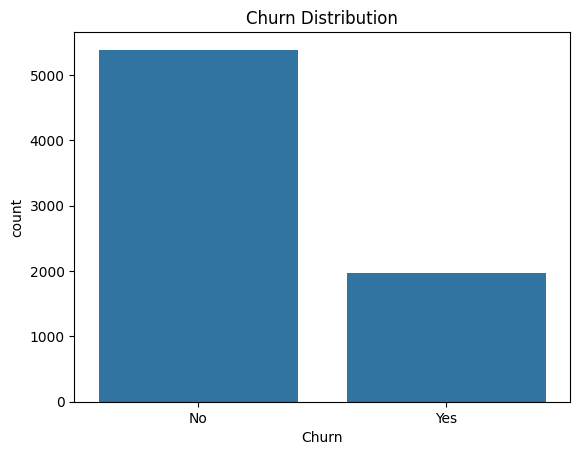

In [ ]:
sns.countplot(x='Churn', data=df_original)
plt.title("Churn Distribution")
plt.show()

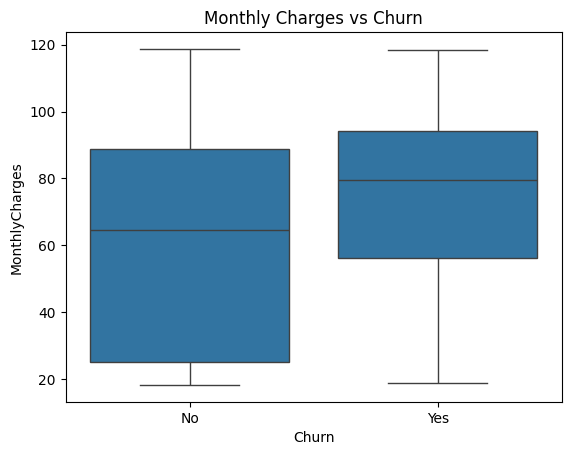

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_original)
plt.title("Monthly Charges vs Churn")
plt.show()

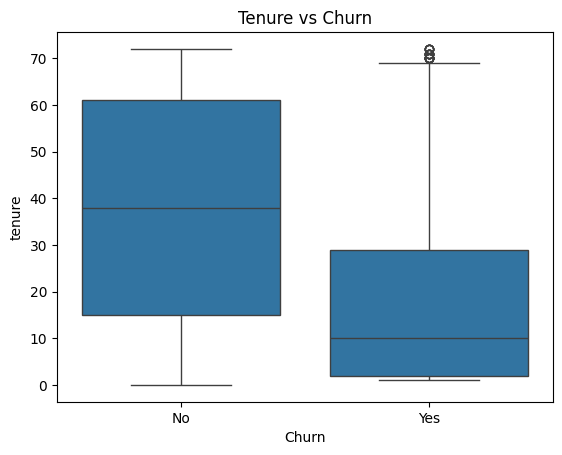

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df_original)
plt.title("Tenure vs Churn")
plt.show()

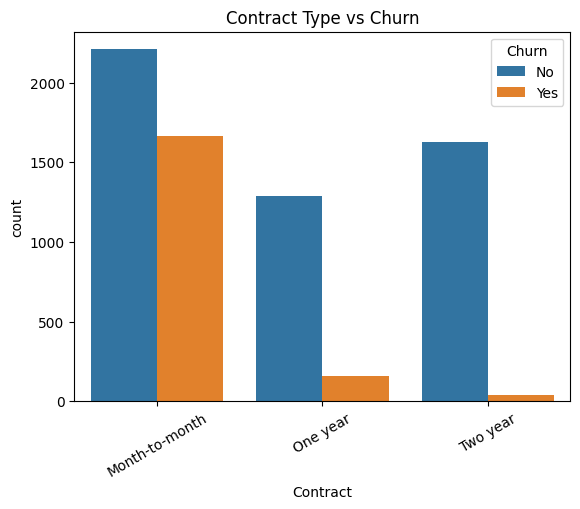

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df_original)
plt.xticks(rotation=30)
plt.title("Contract Type vs Churn")
plt.show()

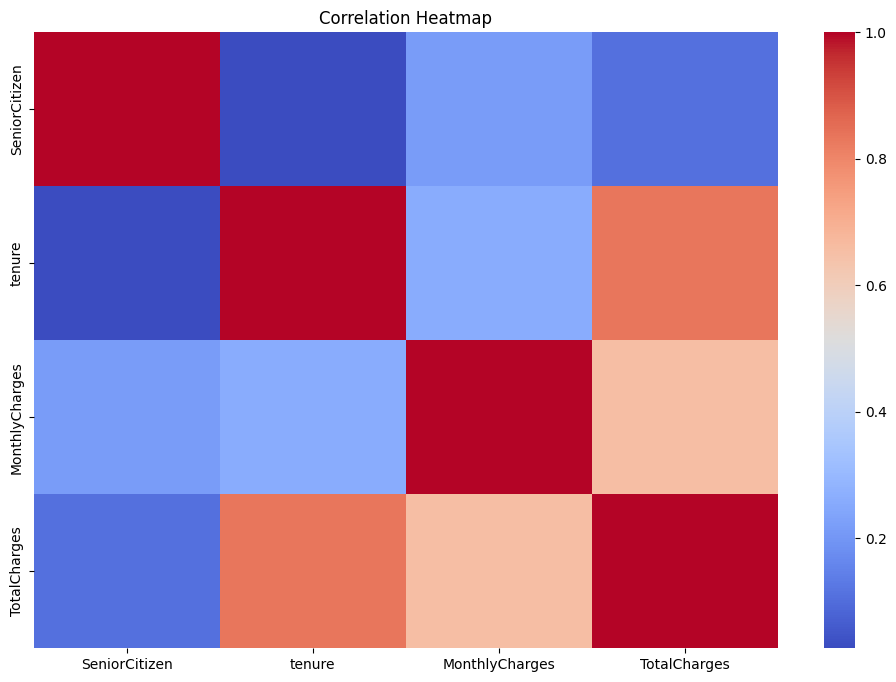

In [ ]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Skewness & Kurtosis of Numeric Features:\n")
for col in numeric_cols:
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    print(f"{col}: Skewness = {s:.3f}, Kurtosis = {k:.3f}")

Skewness & Kurtosis of Numeric Features:

tenure: Skewness = 0.196, Kurtosis = -1.400
MonthlyCharges: Skewness = -0.278, Kurtosis = -1.200
TotalCharges: Skewness = 0.871, Kurtosis = -0.416


/tmp/ipykernel_2368/2910705416.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


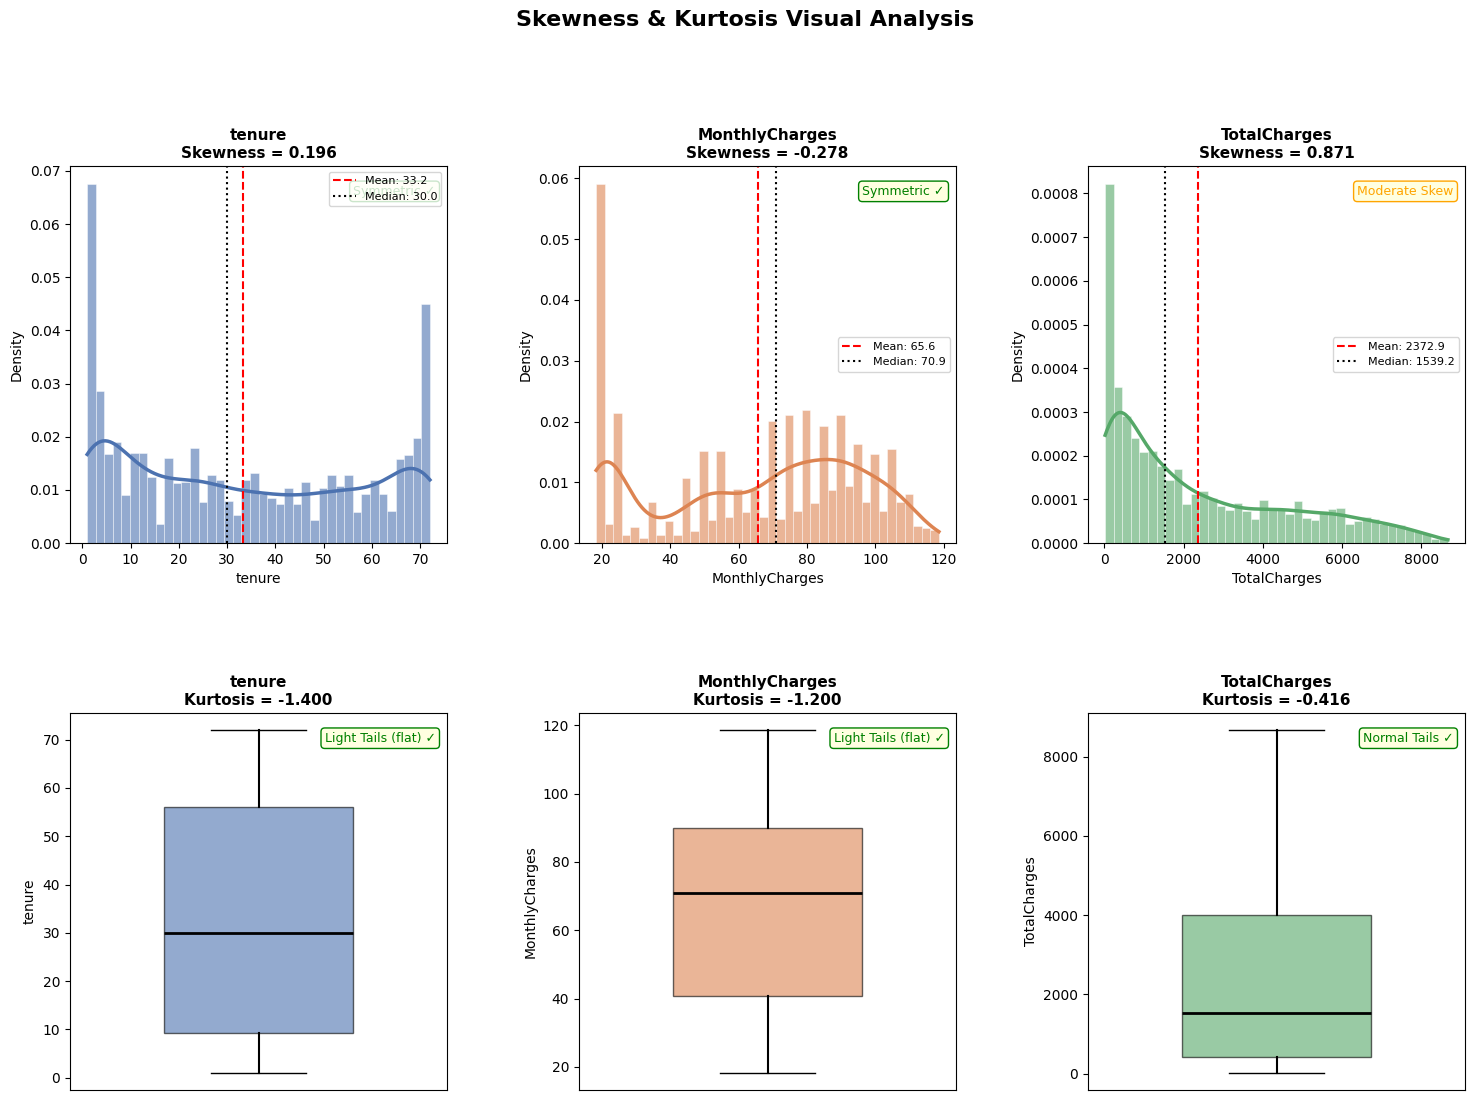

In [ ]:
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Skewness & Kurtosis Visual Analysis', fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    data = df[col].dropna()
    s_val = skew(data)
    k_val = kurtosis(data)

    ax1 = fig.add_subplot(gs[0, i])
    ax1.hist(data, bins=40, color=color, alpha=0.6, density=True, edgecolor='white', linewidth=0.5)

    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    ax1.plot(x_range, kde(x_range), color=color, linewidth=2.5)

    ax1.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax1.axvline(data.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.1f}')

    ax1.set_title(f'{col}\nSkewness = {s_val:.3f}', fontsize=11, fontweight='bold')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Density')
    ax1.legend(fontsize=8)

    if abs(s_val) < 0.5:
        skew_label, skew_color = 'Symmetric ✓', 'green'
    elif abs(s_val) < 1.0:
        skew_label, skew_color = 'Moderate Skew', 'orange'
    else:
        skew_label, skew_color = 'High Skew ⚠', 'red'

    ax1.text(0.97, 0.95, skew_label, transform=ax1.transAxes,
             fontsize=9, color=skew_color, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor=skew_color))

    ax2 = fig.add_subplot(gs[1, i])
    bp = ax2.boxplot(data, vert=True, patch_artist=True, widths=0.5,
                     boxprops=dict(facecolor=color, alpha=0.6),
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor=color, markersize=3, alpha=0.4))

    ax2.set_title(f'{col}\nKurtosis = {k_val:.3f}', fontsize=11, fontweight='bold')
    ax2.set_ylabel(col)
    ax2.set_xticks([])

    if k_val > 1:
        kurt_label, kurt_color = 'Heavy Tails', 'red'
    elif k_val < -0.5:
        kurt_label, kurt_color = 'Light Tails (flat) ✓', 'green'
    else:
        kurt_label, kurt_color = 'Normal Tails ✓', 'green'

    ax2.text(0.97, 0.95, kurt_label, transform=ax2.transAxes,
             fontsize=9, color=kurt_color, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor=kurt_color))

plt.tight_layout()
plt.show()

In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7835820895522388
Confusion Matrix:
 [[353  45]
 [ 71  67]]


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       398
           1       0.60      0.49      0.54       138

    accuracy                           0.78       536
   macro avg       0.72      0.69      0.70       536
weighted avg       0.77      0.78      0.78       536



In [ ]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X.columns)

top_features = importance.sort_values(ascending=False).head(10)

print("Top 10 Important Features:\n")
print(top_features)

Top 10 Important Features:

InternetService_Fiber optic       0.668294
MultipleLines_No phone service    0.490069
SeniorCitizen                     0.372279
PaymentMethod_Electronic check    0.271773
StreamingMovies_Yes               0.216541
PaperlessBilling_Yes              0.213409
Partner_Yes                       0.098182
StreamingTV_Yes                   0.056252
gender_Male                       0.039977
MultipleLines_Yes                 0.036680
dtype: float64


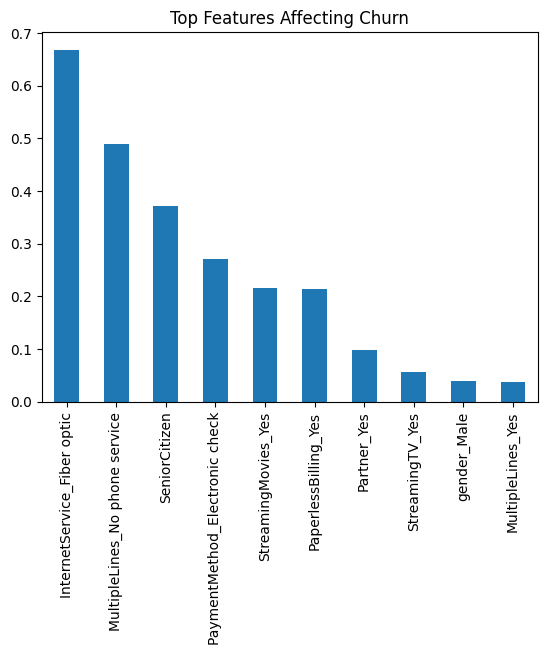

In [ ]:
top_features.plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()

In [ ]:
tenure = int(input("Enter tenure (months): "))
monthly_charges = float(input("Enter monthly charges: "))
total_charges = tenure * monthly_charges
gender = input("Enter gender (Male/Female): ")
contract = input("Enter contract (Month-to-month / One year / Two year): ")

input_data = {
    'tenure': tenure,
    'MonthlyCharges': monthly_charges,
    'TotalCharges': total_charges,


    'gender_Male': 1 if gender == 'Male' else 0,
    'Contract_One year': 1 if contract == 'One year' else 0,
    'Contract_Two year': 1 if contract == 'Two year' else 0
}

for col in X.columns:
    if col not in input_data:
        input_data[col] = 0

input_df = pd.DataFrame([input_data])

input_df = input_df[X.columns]

prediction = model.predict(input_df)

if prediction[0] == 1:
    print("\nCustomer will CHURN")
else:
    print("\nCustomer will NOT CHURN")

Enter tenure (months): 10
Enter monthly charges: 30
Enter gender (Male/Female): Female
Enter contract (Month-to-month / One year / Two year): One year

Customer will NOT CHURN


In [ ]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,2678.000000,2678.000000,2678.000000
mean,33.242345,65.641729,2372.856255
std,24.618749,29.610927,2276.221375
min,1.000000,18.250000,18.800000
25%,9.250000,40.650000,428.912500
50%,30.000000,70.900000,1539.175000
75%,56.000000,89.937500,3992.662500
max,72.000000,118.650000,8670.100000
